# 22 — CNN CIFAR-10 Experiment

This notebook applies the reusable `SmallConvNet` to real CIFAR-10 images. The emphasis is on running a controlled experiment, visualizing its behavior, and interpreting its limitations.

## Goals

- prepare image tensors without train/validation/test leakage;
- verify the pipeline by overfitting a tiny subset;
- train one fixed CNN configuration;
- inspect loss, accuracy, class-level errors, predictions, and filters;
- understand what this small NumPy experiment can and cannot demonstrate.


In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from torchvision.datasets import CIFAR10

from cs231n_practice.classifiers.cnn import SmallConvNet

SEED = 42
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
CLASS_NAMES = (
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
)


## 1. Load reproducible, class-balanced subsets

The reusable CNN uses transparent loop-based convolution and pooling. That is valuable for learning, but much slower than optimized PyTorch kernels. To keep this notebook practical, we use 1,000 training, 250 validation, and 500 test images, with equal representation from all ten classes.

The validation subset comes from the official training set. The official test subset remains separate and is evaluated only after the fixed model has been trained. No hyperparameter search is performed here.


In [14]:
train_dataset = CIFAR10(root=DATA_DIR, train=True, download=True)
test_dataset = CIFAR10(root=DATA_DIR, train=False, download=True)

train_targets = np.asarray(train_dataset.targets, dtype=np.int64)
test_targets = np.asarray(test_dataset.targets, dtype=np.int64)
split_generator = np.random.default_rng(SEED)

def balanced_indices(labels, examples_per_class, generator):
    """Select a shuffled, equal-sized subset from every class."""
    selected = []
    for class_index in range(len(CLASS_NAMES)):
        class_indices = np.flatnonzero(labels == class_index)
        selected.extend(generator.permutation(class_indices)[:examples_per_class])
    return generator.permutation(np.asarray(selected, dtype=np.int64))

# Split each class separately so both development subsets stay balanced.
training_indices_parts = []
validation_indices_parts = []
for class_index in range(len(CLASS_NAMES)):
    class_indices = np.flatnonzero(train_targets == class_index)
    class_indices = split_generator.permutation(class_indices)[:125]
    training_indices_parts.append(class_indices[:100])
    validation_indices_parts.append(class_indices[100:125])
training_indices = split_generator.permutation(np.concatenate(training_indices_parts))
validation_indices = split_generator.permutation(np.concatenate(validation_indices_parts))
test_indices = balanced_indices(test_targets, 50, split_generator)

raw_training_images = train_dataset.data[training_indices]
raw_validation_images = train_dataset.data[validation_indices]
raw_test_images = test_dataset.data[test_indices]
y_train = train_targets[training_indices]
y_validation = train_targets[validation_indices]
y_test = test_targets[test_indices]

assert raw_training_images.shape == (1_000, 32, 32, 3)
assert raw_validation_images.shape == (250, 32, 32, 3)
assert raw_test_images.shape == (500, 32, 32, 3)
assert np.array_equal(np.bincount(y_train), np.full(10, 100))
assert np.array_equal(np.bincount(y_validation), np.full(10, 25))
assert np.array_equal(np.bincount(y_test), np.full(10, 50))
print("Train / validation / test:", len(y_train), len(y_validation), len(y_test))


Train / validation / test: 1000 250 500


### Inspect the class-balanced training subset

One image per class verifies that images, labels, and class names still align after selection.


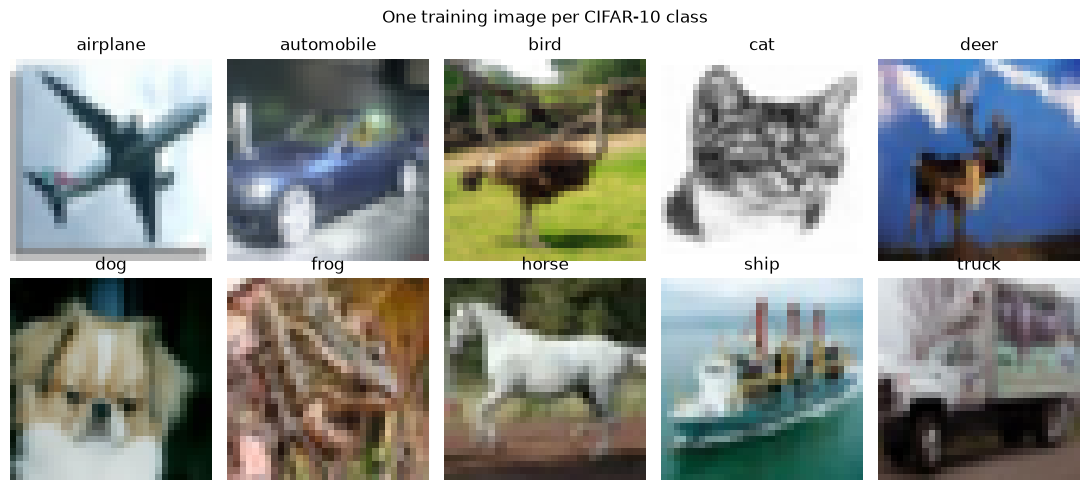

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for class_index, axis in enumerate(axes.ravel()):
    example_index = np.flatnonzero(y_train == class_index)[0]
    axis.imshow(raw_training_images[example_index])
    axis.set_title(CLASS_NAMES[class_index])
    axis.axis("off")
plt.suptitle("One training image per CIFAR-10 class")
plt.tight_layout()
plt.show()


## 2. Downsample and center the images

Each non-overlapping $2\times2$ block is averaged, reducing a $32\times32$ image to $16\times16$. This retains more spatial detail than the earlier $8\times8$ version while remaining substantially cheaper than full-resolution naive convolution. Compared with $8\times8$, the convolution and subsequent affine layer perform roughly four times as much work per example.

Images are scaled to $[0,1]$, converted from NHWC to the project's NCHW convention, and centered using a channel mean fitted on training images only. The same training mean is applied to validation and test images. This is dataset preprocessing, not batch normalization.


In [16]:
def downsample_to_nchw(images):
    """Average 2x2 blocks and return float32 NCHW images."""
    images = images.astype(np.float32) / 255.0
    downsampled = images.reshape(-1, 16, 2, 16, 2, 3).mean(axis=(2, 4))
    return downsampled.transpose(0, 3, 1, 2)

X_train_raw = downsample_to_nchw(raw_training_images)
X_validation_raw = downsample_to_nchw(raw_validation_images)
X_test_raw = downsample_to_nchw(raw_test_images)

training_channel_mean = X_train_raw.mean(axis=(0, 2, 3), keepdims=True)
X_train = X_train_raw - training_channel_mean
X_validation = X_validation_raw - training_channel_mean
X_test = X_test_raw - training_channel_mean

assert X_train.shape == (1_000, 3, 16, 16)
assert training_channel_mean.shape == (1, 3, 1, 1)
np.testing.assert_allclose(X_train.mean(axis=(0, 2, 3)), 0.0, atol=1e-6)
print("Model input shape:", X_train.shape)
print("Training RGB mean:", training_channel_mean.ravel())


Model input shape: (1000, 3, 16, 16)
Training RGB mean: [0.48513296 0.4776008  0.443933  ]


The $16\times16$ versions retain more object structure than $8\times8$ images, although some fine detail is still lost.


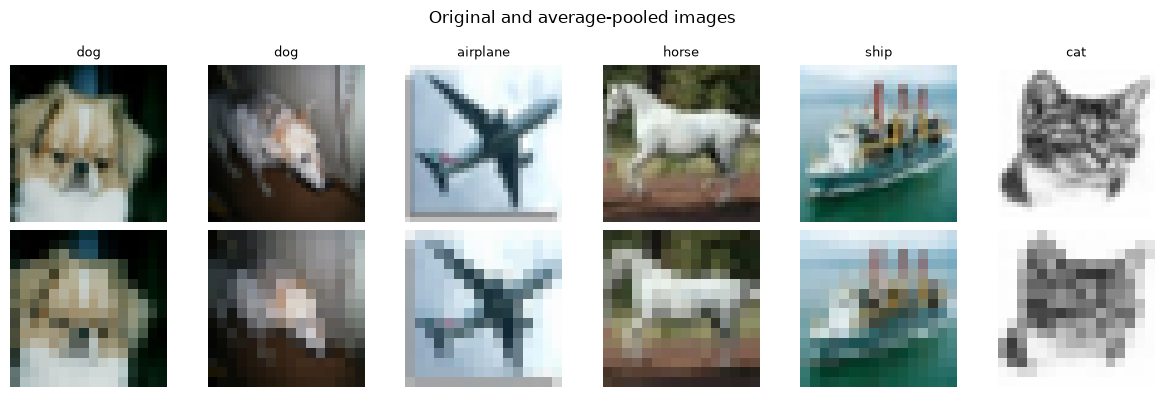

In [17]:
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for column in range(6):
    axes[0, column].imshow(raw_training_images[column])
    axes[1, column].imshow(np.clip(X_train_raw[column].transpose(1, 2, 0), 0, 1))
    axes[0, column].set_title(CLASS_NAMES[y_train[column]], fontsize=9)
    axes[0, column].axis("off")
    axes[1, column].axis("off")
axes[0, 0].set_ylabel("32x32")
axes[1, 0].set_ylabel("16x16")
plt.suptitle("Original and average-pooled images")
plt.tight_layout()
plt.show()


## 3. Diagnostic: overfit a tiny subset

Before the main run, the CNN should be able to memorize 20 examples. This checks that data shapes, labels, forward/backward passes, and SGD work together. It is a debugging diagnostic—not evidence of generalization.


Tiny-subset accuracy: 1.000


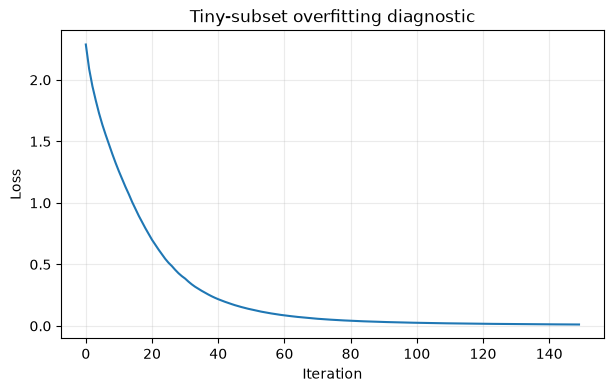

In [18]:
TINY_SIZE = 20
tiny_model = SmallConvNet(
    input_shape=(3, 16, 16),
    num_filters=6,
    filter_size=3,
    hidden_dim=32,
    num_classes=10,
    seed=SEED + 1,
)
tiny_losses = tiny_model.train(
    X_train[:TINY_SIZE],
    y_train[:TINY_SIZE],
    learning_rate=0.1,
    batch_size=TINY_SIZE,
    num_iterations=150,
    seed=SEED + 1,
)
tiny_accuracy = np.mean(tiny_model.predict(X_train[:TINY_SIZE]) == y_train[:TINY_SIZE])
print(f"Tiny-subset accuracy: {tiny_accuracy:.3f}")
assert tiny_losses[-20:].mean() < tiny_losses[:20].mean()
assert tiny_accuracy >= 0.90

plt.figure(figsize=(7, 4))
plt.plot(tiny_losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Tiny-subset overfitting diagnostic")
plt.grid(alpha=0.25)
plt.show()


## 4. Train one fixed baseline CNN

The architecture is

```text
3x16x16 image -> conv(6 filters, 3x3) -> ReLU -> 2x2 max pool
           -> affine(32) -> ReLU -> affine(10) -> softmax loss
```

The configuration is fixed before looking at validation or test results. We use 300 minibatch SGD iterations. The loss is stochastic because each point comes from a different minibatch. At $16\times16$, each iteration is expected to take roughly four times as long as its $8\times8$ counterpart.


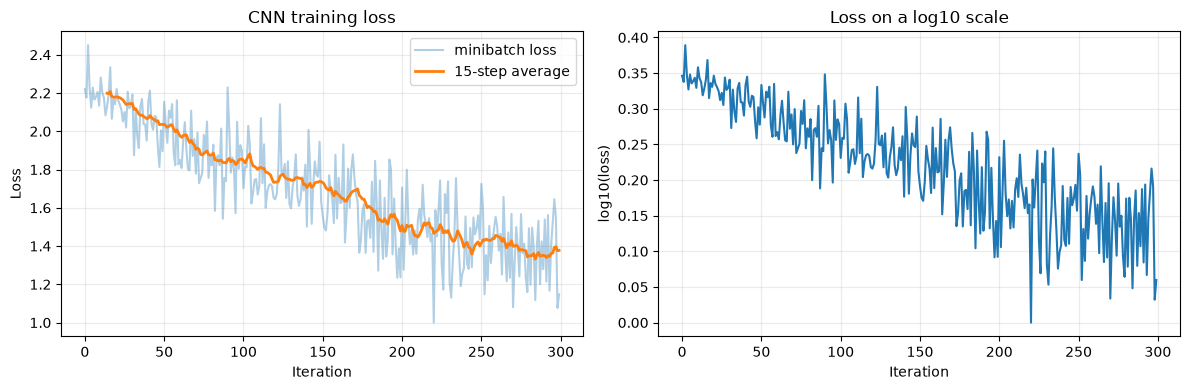

In [19]:
model = SmallConvNet(
    input_shape=(3, 16, 16),
    num_filters=6,
    filter_size=3,
    hidden_dim=32,
    num_classes=10,
    seed=SEED + 10,
)
loss_history = model.train(
    X_train,
    y_train,
    learning_rate=0.1,
    regularization_strength=1e-4,
    batch_size=32,
    num_iterations=300,
    seed=SEED + 10,
)

def moving_average(values, window=15):
    """Return a simple moving average for a less noisy visualization."""
    return np.convolve(values, np.ones(window) / window, mode="valid")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(loss_history, alpha=0.35, label="minibatch loss")
axes[0].plot(
    np.arange(14, len(loss_history)),
    moving_average(loss_history),
    linewidth=2,
    label="15-step average",
)
axes[0].set(title="CNN training loss", xlabel="Iteration", ylabel="Loss")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(np.log10(loss_history))
axes[1].set(title="Loss on a log10 scale", xlabel="Iteration", ylabel="log10(loss)")
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 5. Accuracy and generalization gap

Training accuracy measures fit to examples used for optimization. Validation accuracy estimates generalization during development. The test subset is reported once for this fixed procedure. Random guessing on balanced CIFAR-10 gives approximately 10% accuracy.


     train: 0.560
validation: 0.352
      test: 0.390
Generalization gap: 0.208


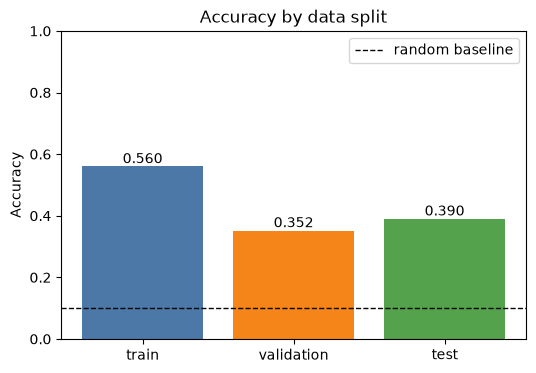

In [20]:
training_predictions = model.predict(X_train)
validation_predictions = model.predict(X_validation)
test_predictions = model.predict(X_test)

accuracies = {
    "train": np.mean(training_predictions == y_train),
    "validation": np.mean(validation_predictions == y_validation),
    "test": np.mean(test_predictions == y_test),
}
for split, accuracy in accuracies.items():
    print(f"{split:>10}: {accuracy:.3f}")
print(f"Generalization gap: {accuracies['train'] - accuracies['validation']:.3f}")

plt.figure(figsize=(6, 4))
bars = plt.bar(accuracies.keys(), accuracies.values(), color=("#4C78A8", "#F58518", "#54A24B"))
plt.axhline(0.1, color="black", linestyle="--", linewidth=1, label="random baseline")
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Accuracy by data split")
plt.bar_label(bars, fmt="%.3f")
plt.legend()
plt.show()


## 6. Confusion matrix

Rows represent true classes and columns represent predicted classes. Row normalization answers: *of all examples from this true class, what fraction received each prediction?* The diagonal contains correct predictions; off-diagonal cells reveal systematic class confusions.


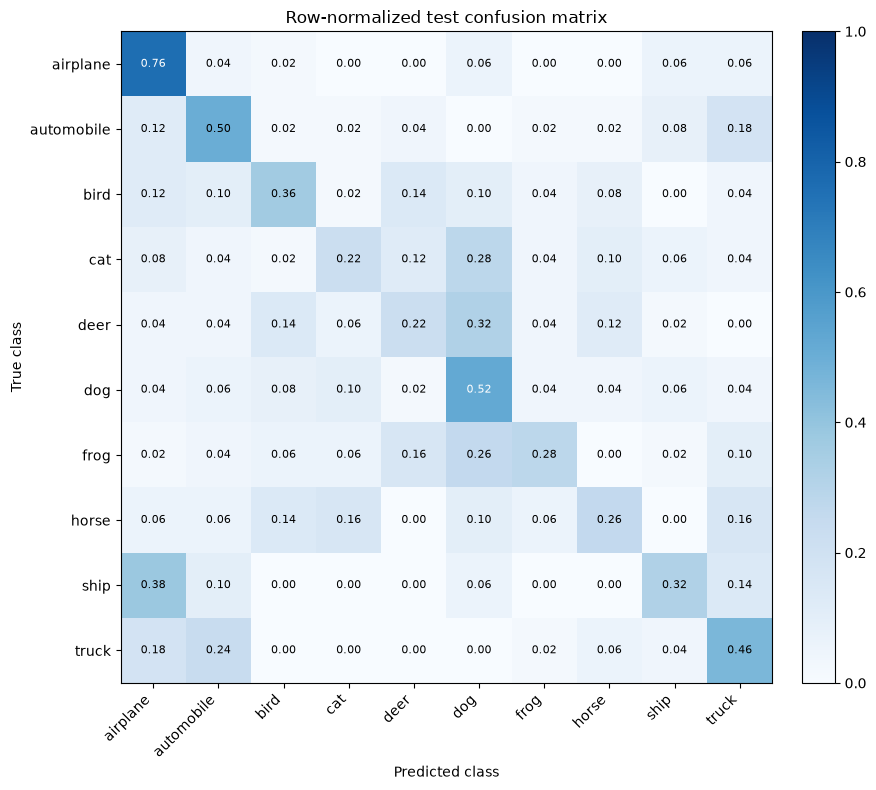

      ship -> airplane  : 0.38
      deer -> dog       : 0.32
       cat -> dog       : 0.28
      frog -> dog       : 0.26
     truck -> automobile: 0.24


In [21]:
confusion = np.zeros((10, 10), dtype=np.int64)
np.add.at(confusion, (y_test, test_predictions), 1)
normalized_confusion = confusion / confusion.sum(axis=1, keepdims=True)

fig, axis = plt.subplots(figsize=(9, 8))
image = axis.imshow(normalized_confusion, cmap="Blues", vmin=0, vmax=1)
for row in range(10):
    for column in range(10):
        value = normalized_confusion[row, column]
        axis.text(
            column, row, f"{value:.2f}", ha="center", va="center",
            color="white" if value > 0.5 else "black", fontsize=8,
        )
axis.set(
    xticks=np.arange(10), yticks=np.arange(10),
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    xlabel="Predicted class", ylabel="True class",
    title="Row-normalized test confusion matrix",
)
plt.setp(axis.get_xticklabels(), rotation=45, ha="right")
fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

off_diagonal = normalized_confusion.copy()
np.fill_diagonal(off_diagonal, -1)
for flat_index in np.argsort(off_diagonal.ravel())[-5:][::-1]:
    true_class, predicted_class = np.unravel_index(flat_index, off_diagonal.shape)
    print(
        f"{CLASS_NAMES[true_class]:>10} -> {CLASS_NAMES[predicted_class]:<10}: "
        f"{off_diagonal[true_class, predicted_class]:.2f}"
    )


## 7. Inspect correct predictions and mistakes

Aggregate accuracy cannot show whether errors are understandable. The following grid displays 12 correct predictions and 12 mistakes. Because this model produces class scores rather than calibrated probabilities, the titles show only predicted and true labels.


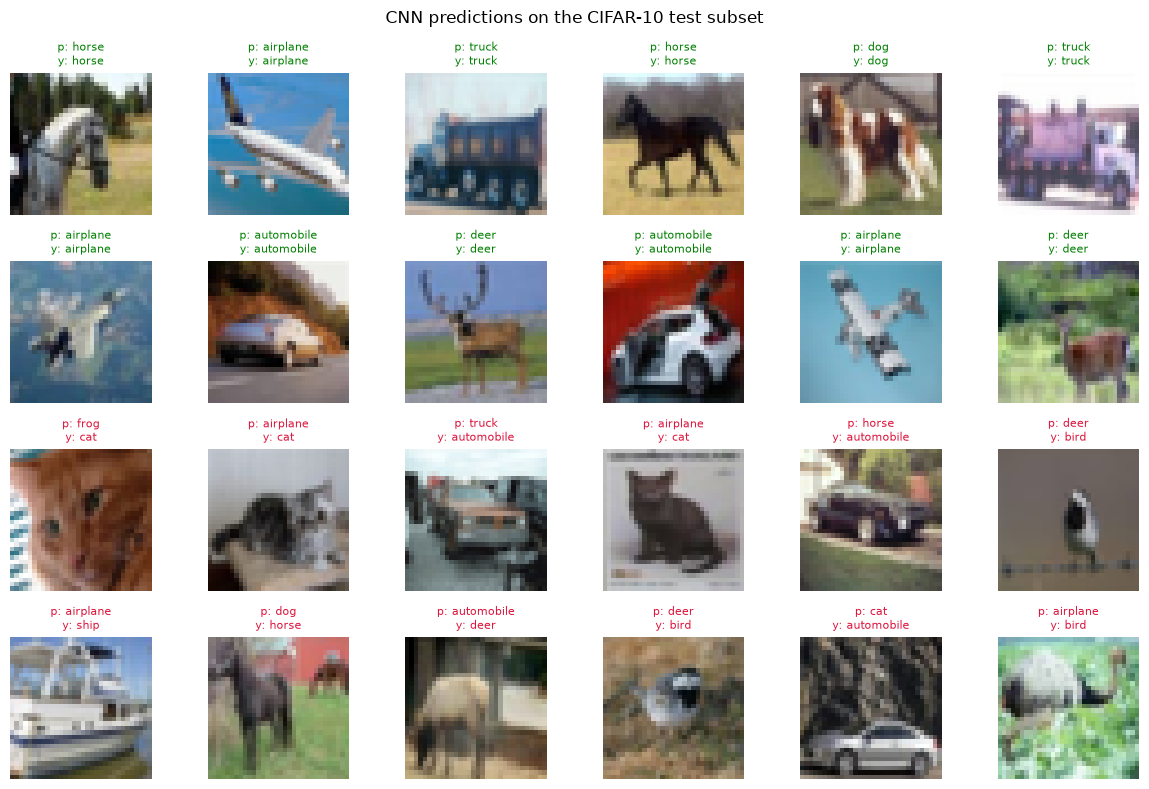

In [22]:
correct_indices = np.flatnonzero(test_predictions == y_test)[:12]
incorrect_indices = np.flatnonzero(test_predictions != y_test)[:12]
display_indices = np.concatenate((correct_indices, incorrect_indices))

fig, axes = plt.subplots(4, 6, figsize=(12, 8))
for axis, index in zip(axes.ravel(), display_indices):
    axis.imshow(raw_test_images[index])
    predicted = CLASS_NAMES[test_predictions[index]]
    actual = CLASS_NAMES[y_test[index]]
    title_color = "green" if predicted == actual else "crimson"
    axis.set_title(f"p: {predicted}\ny: {actual}", color=title_color, fontsize=8)
    axis.axis("off")
axes[0, 0].set_ylabel("Correct")
axes[2, 0].set_ylabel("Mistakes")
plt.suptitle("CNN predictions on the CIFAR-10 test subset")
plt.tight_layout()
plt.show()


## 8. Visualize the learned convolution filters

Each first-layer filter has shape $3\times3\times3$: three color channels and a $3\times3$ spatial footprint. For display, every filter is independently rescaled to $[0,1]$. This makes its pattern visible but removes information about its absolute magnitude relative to other filters.


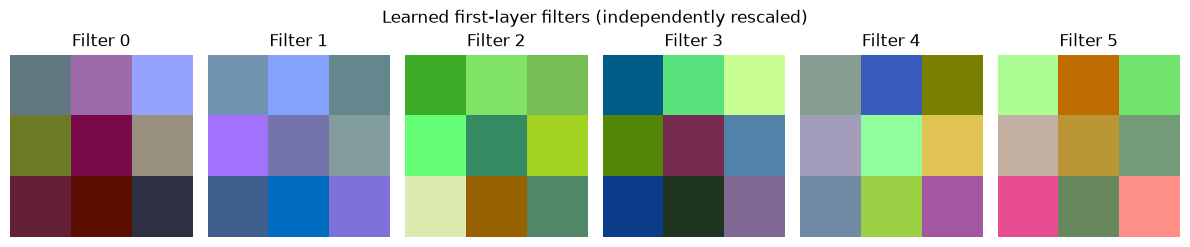

In [23]:
filters = model.parameters["W1"]
fig, axes = plt.subplots(1, len(filters), figsize=(12, 2.5))
for filter_index, (axis, weights) in enumerate(zip(axes, filters)):
    image = weights.transpose(1, 2, 0)
    image = (image - image.min()) / (np.ptp(image) + 1e-12)
    axis.imshow(image, interpolation="nearest")
    axis.set_title(f"Filter {filter_index}")
    axis.axis("off")
plt.suptitle("Learned first-layer filters (independently rescaled)")
plt.tight_layout()
plt.show()


## 9. Interpretation and limitations

Use the generated results to consider the following points:

- A successful tiny-subset diagnostic supports the correctness of the assembled pipeline, but it does not prove that the model generalizes.
- A falling but noisy loss is expected with minibatch SGD. The moving average exposes the broader trend.
- Training accuracy above validation accuracy indicates some overfitting; equally low values may instead indicate underfitting or insufficient optimization.
- The confusion matrix reveals whether errors concentrate in visually related classes and whether the model overpredicts particular labels.
- First-layer filters may show color contrasts or simple local patterns, but six tiny filters provide very limited feature diversity.
- Downsampling, the small balanced subsets, only 300 updates, one configuration, and naive layers make this a learning experiment—not a competitive CIFAR-10 benchmark.
- The result comes from one random seed. Repeated runs would be needed to estimate variability.

### Where normalization and dropout fit

The baseline above does not use normalization or dropout. The extended `SmallConvNet` can now place batch normalization after its hidden affine layer and inverted dropout after the following ReLU. It maintains running statistics, learns $\gamma$ and $\beta$, and switches both operations between training and inference behavior.

The next experiment compares that extended path with the baseline while holding the remaining settings fixed.


## 10. Separate normalization and dropout effects

The earlier comparison changed batch normalization and dropout simultaneously, so it could not reveal which component caused which effect. This controlled experiment trains four fresh models:

1. baseline;
2. batch normalization only;
3. dropout only;
4. batch normalization and dropout.

All models start from the same weight seed and receive the same minibatch sequence. They use learning rate `0.05` and only 120 iterations, making this a shorter comparison than the main baseline run. Dropout uses keep probability $p=0.8$, so approximately 20% of hidden activations are removed during training.

Only training and validation accuracy are compared. The test set is intentionally not evaluated again while we investigate development choices.


baseline              train=0.333  validation=0.212  gap=0.121
batch norm            train=0.448  validation=0.276  gap=0.172
dropout               train=0.320  validation=0.240  gap=0.080
batch norm + dropout  train=0.427  validation=0.288  gap=0.139


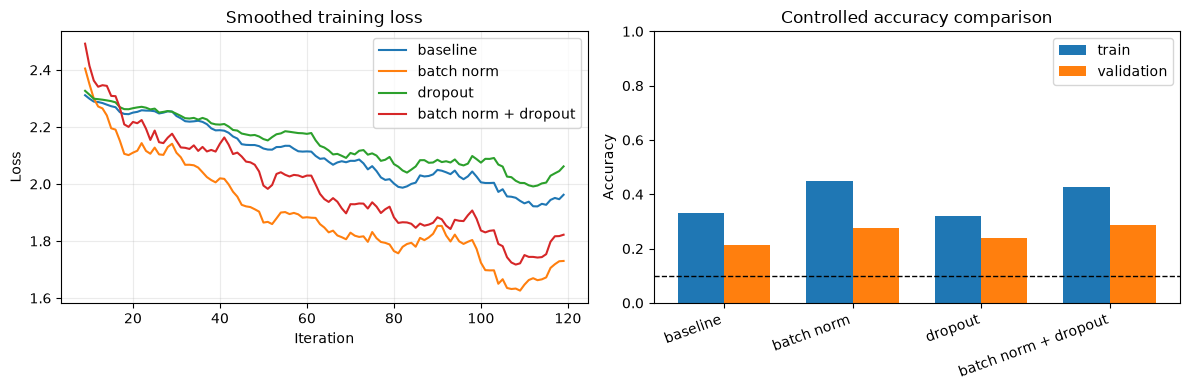

In [24]:
CONTROLLED_LEARNING_RATE = 0.05
CONTROLLED_ITERATIONS = 120
controlled_configurations = (
    {"name": "baseline", "use_batchnorm": False, "dropout_keep_probability": None},
    {"name": "batch norm", "use_batchnorm": True, "dropout_keep_probability": None},
    {"name": "dropout", "use_batchnorm": False, "dropout_keep_probability": 0.8},
    {"name": "batch norm + dropout", "use_batchnorm": True, "dropout_keep_probability": 0.8},
)
controlled_results = []

for configuration in controlled_configurations:
    experiment_model = SmallConvNet(
        input_shape=(3, 16, 16),
        num_filters=6,
        filter_size=3,
        hidden_dim=32,
        num_classes=10,
        use_batchnorm=configuration["use_batchnorm"],
        dropout_keep_probability=configuration["dropout_keep_probability"],
        seed=SEED + 30,
    )
    experiment_losses = experiment_model.train(
        X_train,
        y_train,
        learning_rate=CONTROLLED_LEARNING_RATE,
        regularization_strength=1e-4,
        batch_size=32,
        num_iterations=CONTROLLED_ITERATIONS,
        seed=SEED + 30,
    )
    experiment_accuracies = {
        "train": np.mean(experiment_model.predict(X_train) == y_train),
        "validation": np.mean(experiment_model.predict(X_validation) == y_validation),
    }
    controlled_results.append({
        "name": configuration["name"],
        "model": experiment_model,
        "losses": experiment_losses,
        "accuracies": experiment_accuracies,
    })
    gap = experiment_accuracies["train"] - experiment_accuracies["validation"]
    print(
        f"{configuration['name']:<21} "
        f"train={experiment_accuracies['train']:.3f}  "
        f"validation={experiment_accuracies['validation']:.3f}  "
        f"gap={gap:.3f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
window = 10
iterations = np.arange(window - 1, CONTROLLED_ITERATIONS)
for result in controlled_results:
    axes[0].plot(
        iterations,
        moving_average(result["losses"], window),
        label=result["name"],
    )
axes[0].set(title="Smoothed training loss", xlabel="Iteration", ylabel="Loss")
axes[0].grid(alpha=0.25)
axes[0].legend()

positions = np.arange(len(controlled_results))
width = 0.36
axes[1].bar(
    positions - width / 2,
    [result["accuracies"]["train"] for result in controlled_results],
    width,
    label="train",
)
axes[1].bar(
    positions + width / 2,
    [result["accuracies"]["validation"] for result in controlled_results],
    width,
    label="validation",
)
axes[1].axhline(0.1, color="black", linestyle="--", linewidth=1)
axes[1].set(
    title="Controlled accuracy comparison",
    ylabel="Accuracy",
    xticks=positions,
    xticklabels=[result["name"] for result in controlled_results],
    ylim=(0, 1),
)
plt.setp(axes[1].get_xticklabels(), rotation=20, ha="right")
axes[1].legend()
plt.tight_layout()
plt.show()


### Reading the controlled comparison

Compare batch normalization only with the fresh baseline to estimate its effect under this budget. Compare dropout only with the baseline to estimate dropout's effect. The fourth model shows whether their combination behaves differently from either component alone.

A lower training accuracy is not automatically worse: dropout deliberately makes fitting harder, and a smaller train–validation gap may indicate stronger regularization. Validation accuracy is the main comparison. Batch normalization can change the most suitable learning rate, while dropout may need more iterations to reach the same fit. Holding the settings fixed improves causal interpretation, but does not give every variant its individually optimal configuration.

These four short runs should therefore answer *what each component does under one shared training setup*, not which configuration has the highest achievable CIFAR-10 accuracy.


- Batch normalization accelerated fitting and improved validation accuracy, but increased the gap.
- Dropout slightly reduced training accuracy while improving validation accuracy and reducing the gap—classic regularization behavior.
- Combining them retained much of batch normalization’s optimization benefit while dropout reduced some of its overfitting.
- Under this short shared budget, the combination achieved the best validation accuracy